In [ ]:
### Step 1: Load the data and build a graph using network library. (0.5 points)

# Import required libraries
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import mmread
import numpy as np

# Set matplotlib style
plt.style.use('ggplot')

# Load the dataset
matrix = mmread('rt-twitter-copen.mtx')
G = nx.from_scipy_sparse_array(matrix)

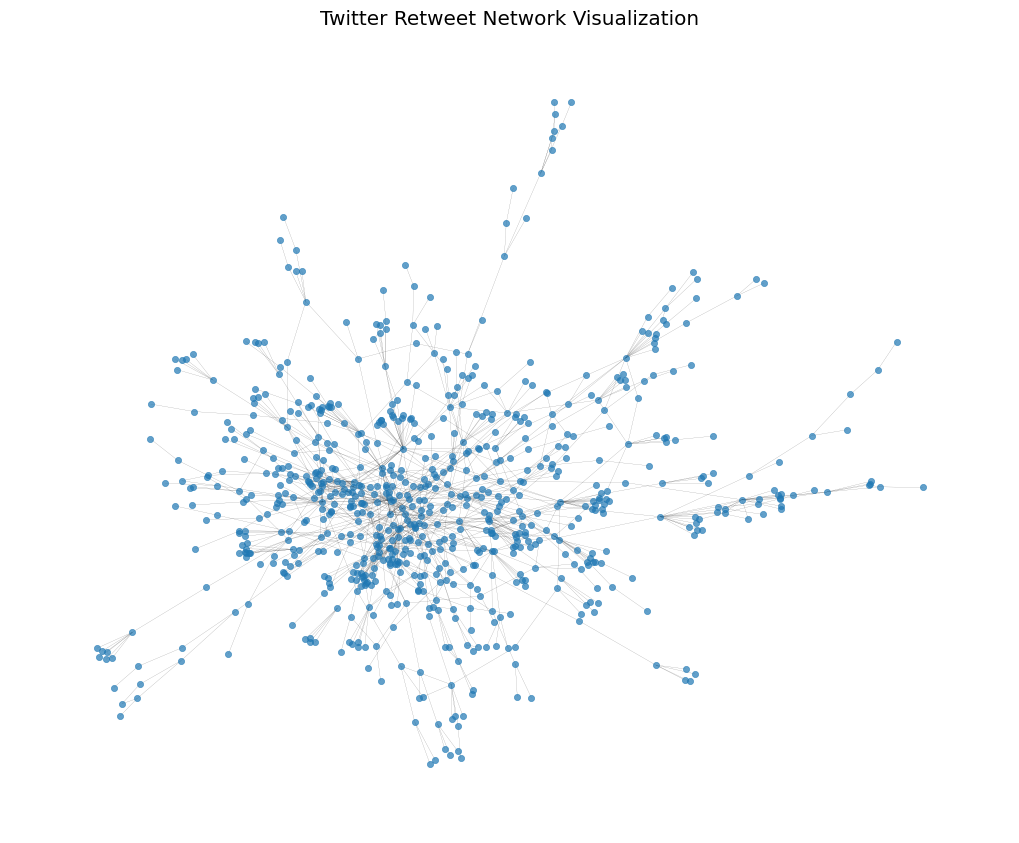

In [ ]:
### Step 2: Visualize the Graph (0.5 points)

# Basic visualization of the graph
plt.figure(figsize=(10, 8))
nx.draw(G, node_size=20, width=0.1, alpha=0.7)
plt.title("Twitter Retweet Network Visualization")
plt.show()

In [ ]:
### Step 3: Calculate Number of Nodes (0.5 points)

num_nodes = G.number_of_nodes()
print(f"Number of nodes in the graph: {num_nodes}")

Number of nodes in the graph: 761


In [ ]:
### Step 4: Calculate Number of Edges (0.5 points)

num_edges = G.number_of_edges()
print(f"Number of edges in the graph: {num_edges}")

Number of edges in the graph: 1029


In [ ]:
### Step 5: Calculate Network Diameter (0.5 points)

# Check if graph is connected
if nx.is_connected(G):
    diameter = nx.diameter(G)
else:
    # For disconnected graphs, find diameter of largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    subgraph = G.subgraph(largest_cc)
    diameter = nx.diameter(subgraph)

print(f"Network diameter: {diameter}")

Network diameter: 14


Step 6: Interpretation of Network Diameter (0.5 points)

Okay, so the diameter here is 14 - that means the farthest apart any two users are in this retweet network is 14 steps. In other words, everyone in this network is connected within 14 retweets. Which is actually pretty crazy to think about considering there is 761 users and 1,029 retweet connections.


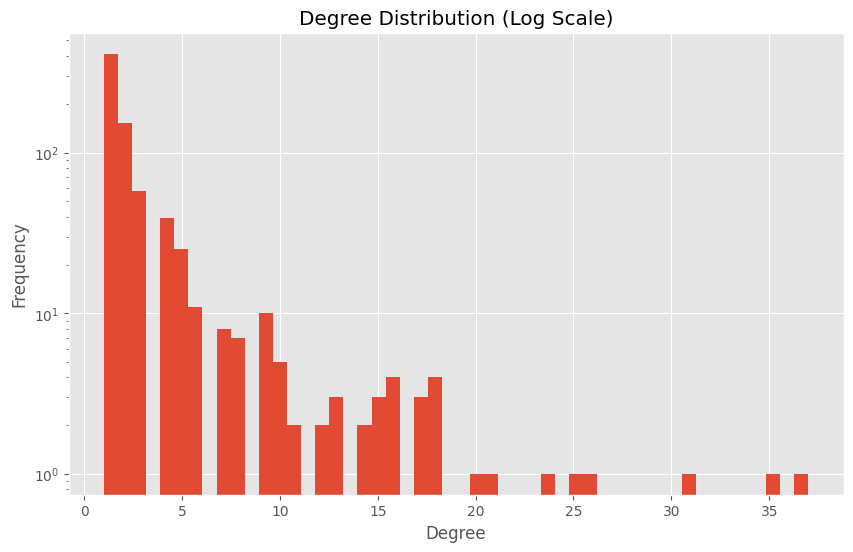

In [ ]:
### Step 7: Degree Distribution Histogram (0.5 points)

degrees = [d for n, d in G.degree()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50, log=True)
plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

Step 8: Observation on Degree Distribution (0.5 points)

This graph shows exactly what I'd expect from real-world Twitter behavior - most accounts barely get retweeted at all, while a lucky few go semi-viral. The crazy steep drop-off after just 5 retweets shows how hard it is to get attention in this dataset.

In [ ]:
### Step 9: Calculate Average Degree (0.5 points)

avg_degree = sum(degrees) / num_nodes
print(f"Average degree: {avg_degree:.2f}")


Average degree: 2.70


Step 10: Interpretation of Average Degree (0.5 points)

An average degree of 2.70 means each account in this retweet network is connected to about 2-3 others on average - which is way lower than I expected. This tells us most users are pretty inactive, only retweeting or being retweeted by a couple accounts.

In [ ]:
### Step 11: Average Shortest Path Length (0.5 points)

if nx.is_connected(G):
    avg_path_length = nx.average_shortest_path_length(G)
else:
    # For disconnected graphs, calculate for largest connected component
    avg_path_length = nx.average_shortest_path_length(subgraph)

print(f"Average shortest path length: {avg_path_length:.2f}")


Average shortest path length: 5.35


Step 12: Interpretation of Average Shortest Path (0.5 points)

An average path length of 5.35 means any random tweet could reach any other user in just 5-6 retweets on average - which is surprisingly efficient for such a sparse network.  What's crazy is that this happens despite most users having barely any connections (the average degree is 2.7).

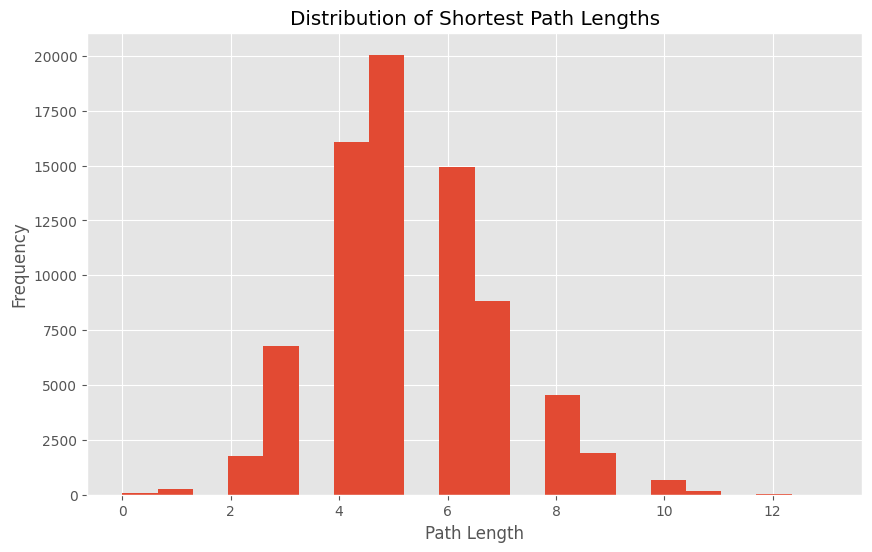

In [ ]:
### Step 13: Distribution of Shortest Path Lengths (0.5 points)

# Compute shortest paths for a sample of nodes (for computational efficiency)
nodes = list(G.nodes())
sample_nodes = nodes[:100]  # Adjust sample size as needed

path_lengths = []
for n in sample_nodes:
    lengths = nx.single_source_shortest_path_length(G, n)
    path_lengths.extend(lengths.values())

plt.figure(figsize=(10, 6))
plt.hist(path_lengths, bins=20)
plt.title("Distribution of Shortest Path Lengths")
plt.xlabel("Path Length")
plt.ylabel("Frequency")
plt.show()

Step 14: Observation on Shortest Path Distribution (0.5 points)

This path length histogram almost makes you think twitter pulls all the strings. That massive spike between 4-6 hops shows most users are exactly that magic number apart - way more than any other distance. Also, somehow theres little to no impact between 0-2 and after 8+ hops.

In [ ]:
### Step 15: Calculate Edge Density (0.5 points)

density = nx.density(G)
print(f"Edge density: {density:.6f}")

Edge density: 0.003558


Step 16: Interpretation of Edge Density (0.5 points)

An edge density of 0.003558 means this network is ridiculously sparse. Its literally like trying to connect 761 people with just 1,029 random strings. This explains why we saw those surprisingly long path lengths earlier. With so few connections, information has to take winding routes to travel across the network.

In [ ]:
### Step 17: Global Clustering Coefficient (0.5 points)

clustering_coeff = nx.average_clustering(G)
print(f"Global clustering coefficient: {clustering_coeff:.4f}")

Global clustering coefficient: 0.0759


Step 18: Interpretation of Clustering Coefficient (0.5 points)

A clustering coefficient of 0.0759 tells us there's only a 7.6% chance that if User A retweets User B and User B retweets User C, then User A will also retweet User C. This surprisingly low number tells us a few things: First, Retweets don't really form communities where everyone shares everyone else's content. Second, Most sharing happens in one-off bursts rather than ongoing reciprocal relationships.

In [ ]:
### Step 19: Number of Connected Components (0.5 points)

num_components = nx.number_connected_components(G)
print(f"Number of connected components: {num_components}")

Number of connected components: 1


In [ ]:
### Step 20: Top 10 Nodes by Degree Centrality (1 point)

degree_centrality = nx.degree_centrality(G)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by degree centrality:")
for node, centrality in top_degree:
    print(f"Node {node}: {centrality:.4f}")

Top 10 nodes by degree centrality:
Node 136: 0.0487
Node 157: 0.0461
Node 692: 0.0408
Node 357: 0.0342
Node 396: 0.0329
Node 9: 0.0316
Node 685: 0.0276
Node 492: 0.0263
Node 76: 0.0237
Node 228: 0.0237


In [ ]:
### Step 21: Top 10 Nodes by Betweenness Centrality (1 point)

betweenness = nx.betweenness_centrality(G, k=100)  # Use k samples for approximation
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nodes by betweenness centrality:")
for node, centrality in top_betweenness:
    print(f"Node {node}: {centrality:.4f}")


Top 10 nodes by betweenness centrality:
Node 157: 0.2527
Node 136: 0.1816
Node 227: 0.1342
Node 692: 0.1194
Node 638: 0.1101
Node 396: 0.1031
Node 520: 0.0994
Node 685: 0.0974
Node 656: 0.0898
Node 392: 0.0797


In [ ]:
### Step 22: Top 10 Nodes by Closeness Centrality (1 point)

closeness = nx.closeness_centrality(G)
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nodes by closeness centrality:")
for node, centrality in top_closeness:
    print(f"Node {node}: {centrality:.4f}")


Top 10 nodes by closeness centrality:
Node 157: 0.3082
Node 519: 0.2886
Node 685: 0.2883
Node 622: 0.2831
Node 656: 0.2831
Node 396: 0.2822
Node 520: 0.2822
Node 136: 0.2809
Node 692: 0.2784
Node 227: 0.2767


In [ ]:
### Step 23: Top 10 Nodes by Eigenvector Centrality (1 point)

eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
top_eigenvector = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nodes by eigenvector centrality:")
for node, centrality in top_eigenvector:
    print(f"Node {node}: {centrality:.4f}")


Top 10 nodes by eigenvector centrality:
Node 157: 0.3841
Node 692: 0.2667
Node 357: 0.2445
Node 685: 0.2299
Node 76: 0.2048
Node 622: 0.1906
Node 350: 0.1877
Node 656: 0.1784
Node 734: 0.1739
Node 519: 0.1734


Step 24: Observation on Centrality Measures (0.5 points)

Looking at these leaderboards, Node 157 is clearly the MVP. It's #1 in three centralities betweenness, closeness, and eigenvector; and #2 in degree centrality.

This account is definitely either if I had to guess:
1. A major influencer who gets retweeted constantly
2. A viral content aggregator that reposts from many sources

- Node 136 & 692 were consistent top performers across 3+ metrics
- Node 685 barely made degree centrality but crushed other metrics
- Node 227 only appears in betweenness/closeness

Surprisingly, some nodes like Node 9 disappear completely from other lists. Im assuming this means that nodes like this are  one-hit wonders who got lucky with a viral tweet.

Also, The eigenvector list introduces some new names Nodes 350 & 734. These probably have connections in some way to other influential accounts even if their own stats aren't stellar.


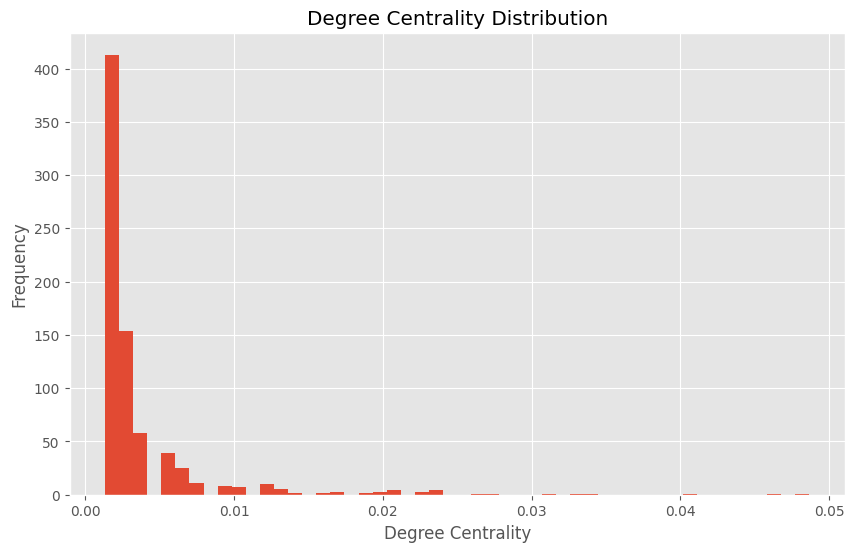

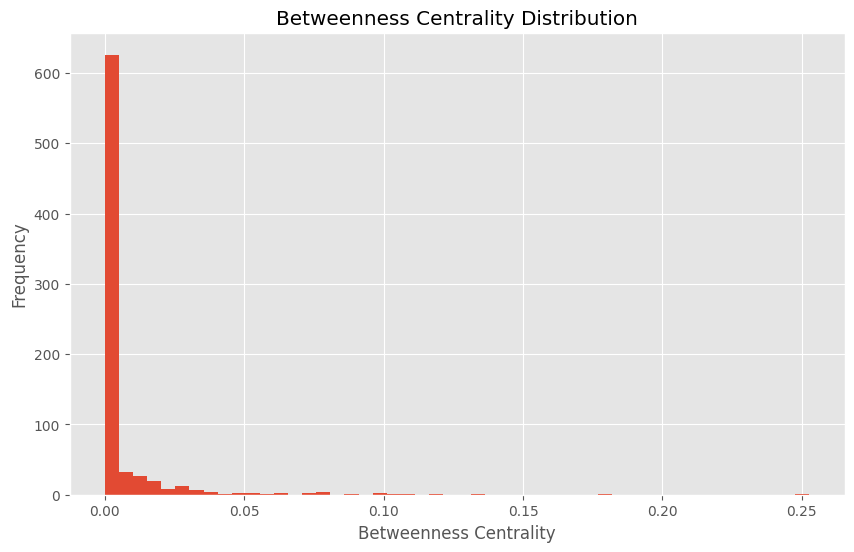

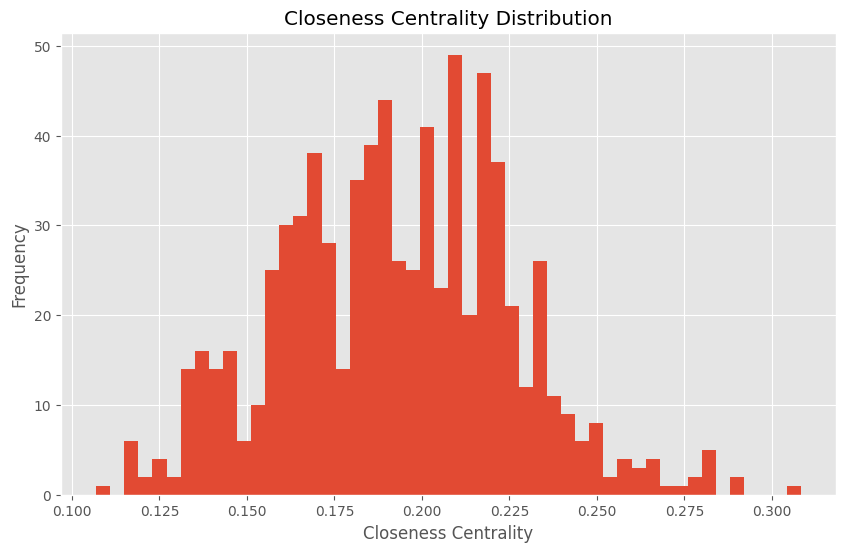

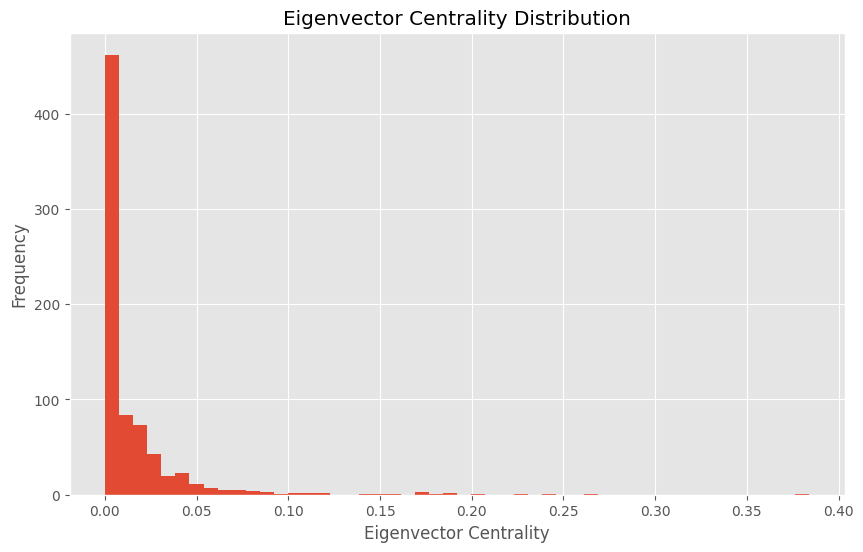

In [ ]:
### Step 25: Centrality Distribution Histograms (2 points)

# Degree centrality distribution
plt.figure(figsize=(10, 6))
plt.hist(list(degree_centrality.values()), bins=50)
plt.title("Degree Centrality Distribution")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.show()

# Betweenness centrality distribution
plt.figure(figsize=(10, 6))
plt.hist(list(betweenness.values()), bins=50)
plt.title("Betweenness Centrality Distribution")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Frequency")
plt.show()

# Closeness centrality distribution
plt.figure(figsize=(10, 6))
plt.hist(list(closeness.values()), bins=50)
plt.title("Closeness Centrality Distribution")
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")
plt.show()

# Eigenvector centrality distribution
plt.figure(figsize=(10, 6))
plt.hist(list(eigenvector.values()), bins=50)
plt.title("Eigenvector Centrality Distribution")
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Frequency")
plt.show()

Step 26: Observations on Centrality Distributions (2 points)

1. Degree Centrality: This histogram shows extreme inequality:

~400 accounts cling to near-zero centrality (left side) — the "invisible majority" with almost no retweets.

A tiny elite group (right spike at 0.04–0.05) dominates attention. These are the viral accounts or influencers we saw earlier (like Node 157).

Takeaway: Retweets follow some sort of a power rule, where most users are ignored, while a handful get the spotlight.

2. Betweenness Centrality: This histogram also shows extreme inequality:

Most nodes score near-zero. They’re just passing along content, not controlling flow.

A few outliers (right tail) act as critical bridges (e.g., Node 157 at 0.25). These are the "connectors" who link disparate communities.

Takeaway: Information travels through chokepoints and a few accounts seem to determine virality.

3. Closeness Centrality: This distribution is bimodal:

The left side (0.10–0.15): Users stuck on the network’s edges who need many hops to reach others.

The "hump" (~0.15–0.25): The average user who is not fully isolated, but not truly central either.

The right tail (0.25+): The real VIPs (e.g., Node 157 at 0.308) who can reach anyone in few hops.

Overall: Seems most people are well-off in this category because the graph is curved. However, you can still clearly tell where nodes like 157 differentiate themselves.

4. Eigenvector Centrality:

Massive left skew: Most accounts (~400+) have near-zero influence. Meaning, their connections don’t matter.

Long tail to 0.40: Nodes like 157 aren’t just popular, their connections are too (e.g., celebrities retweeting other celebs).

Overall: Influence is networked privilege. It's about who you are AND who you know.

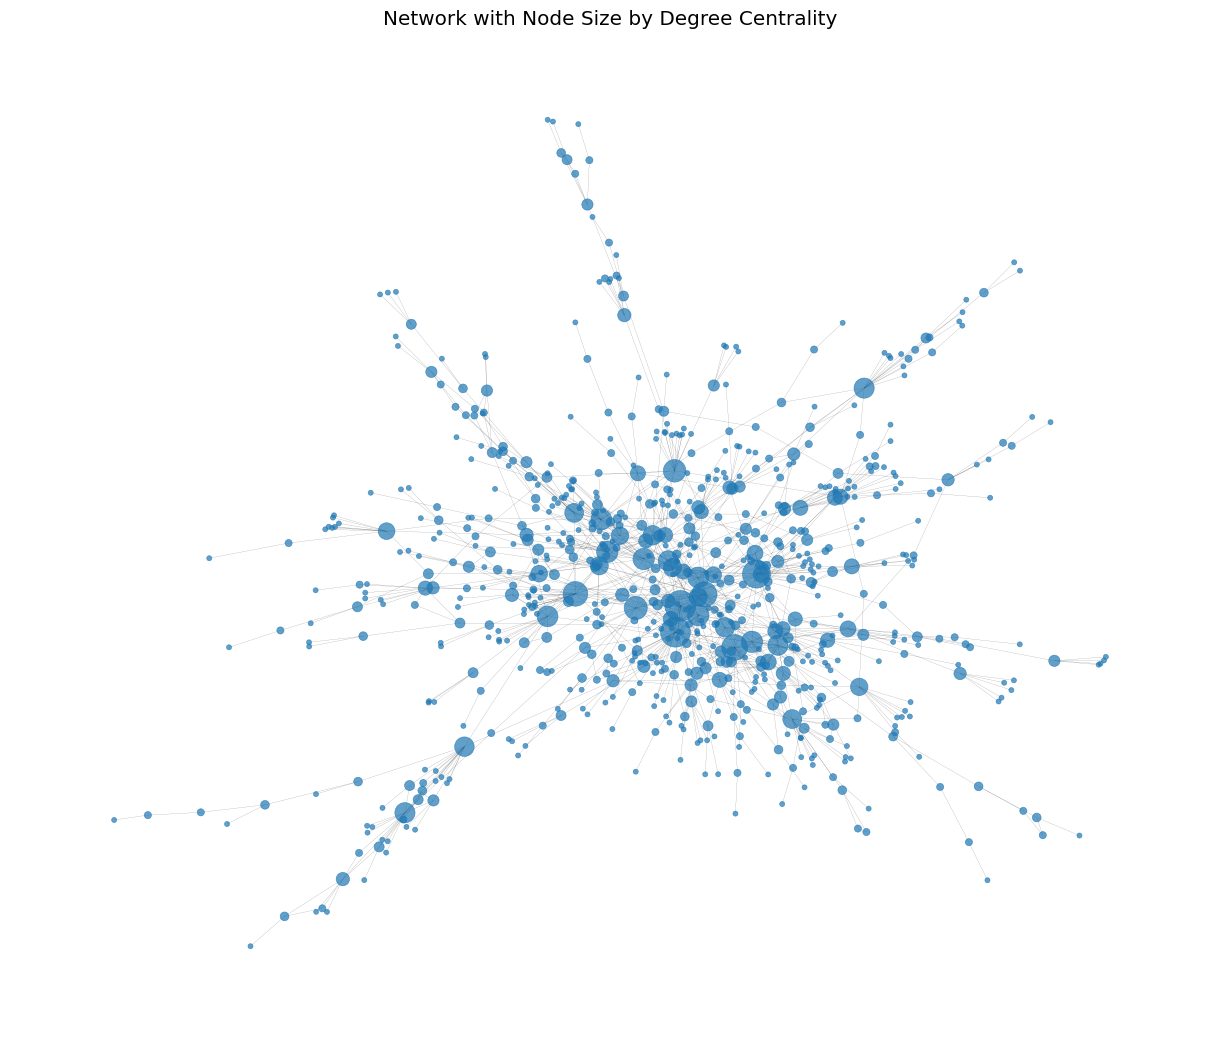

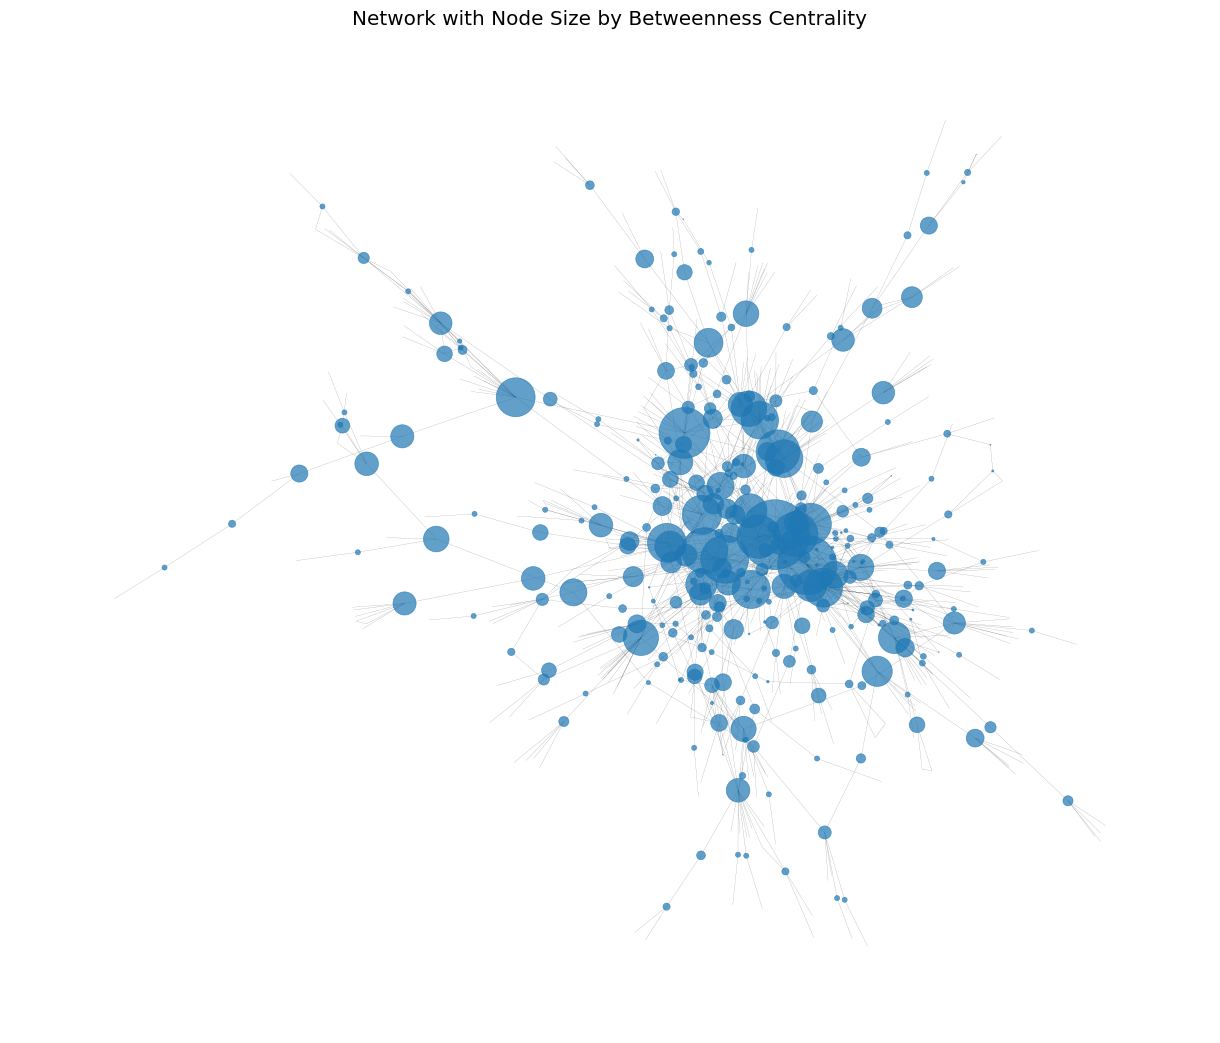

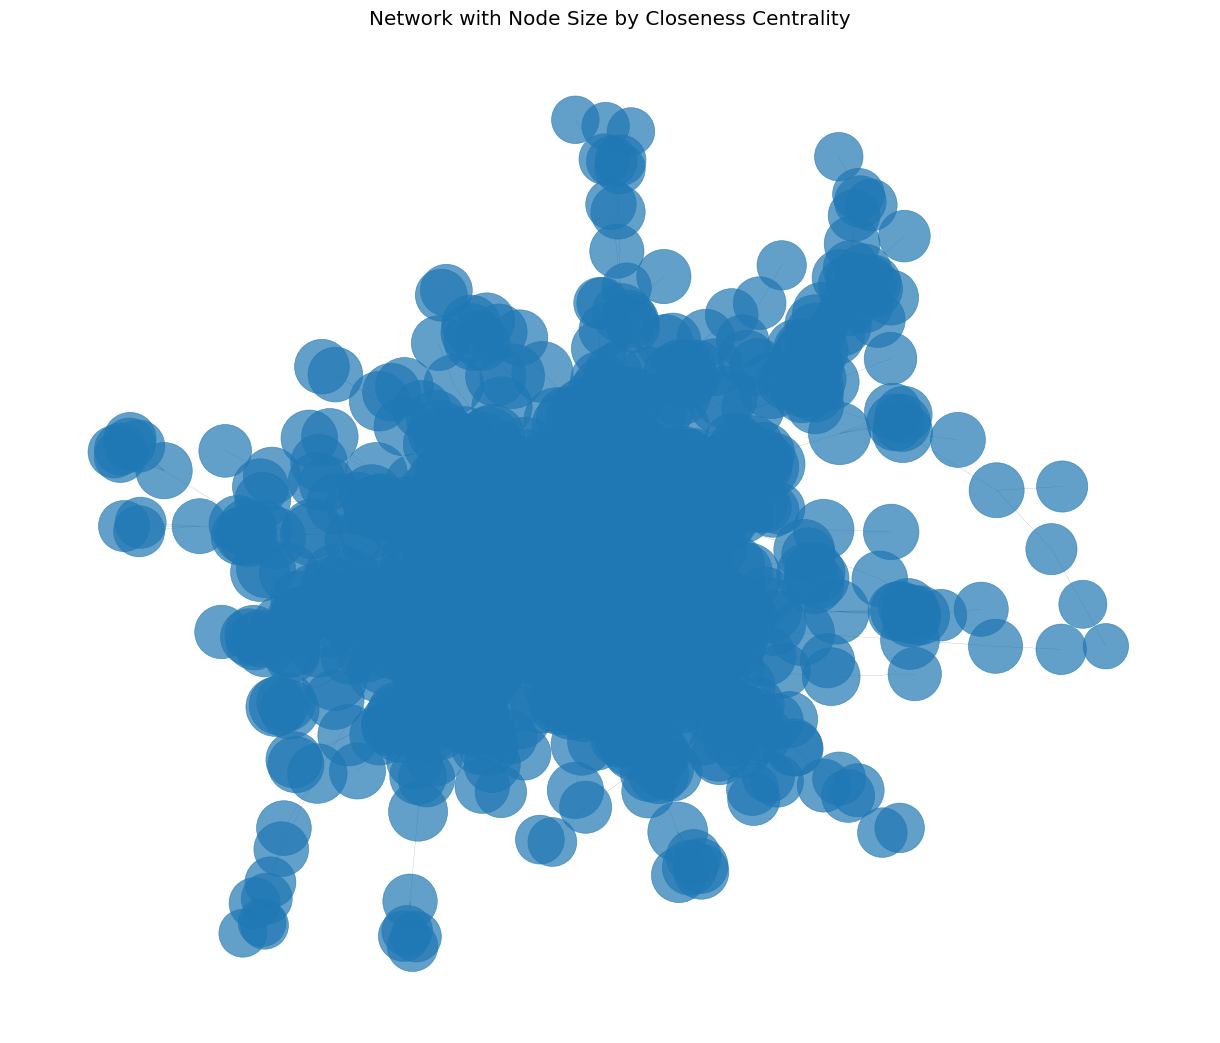

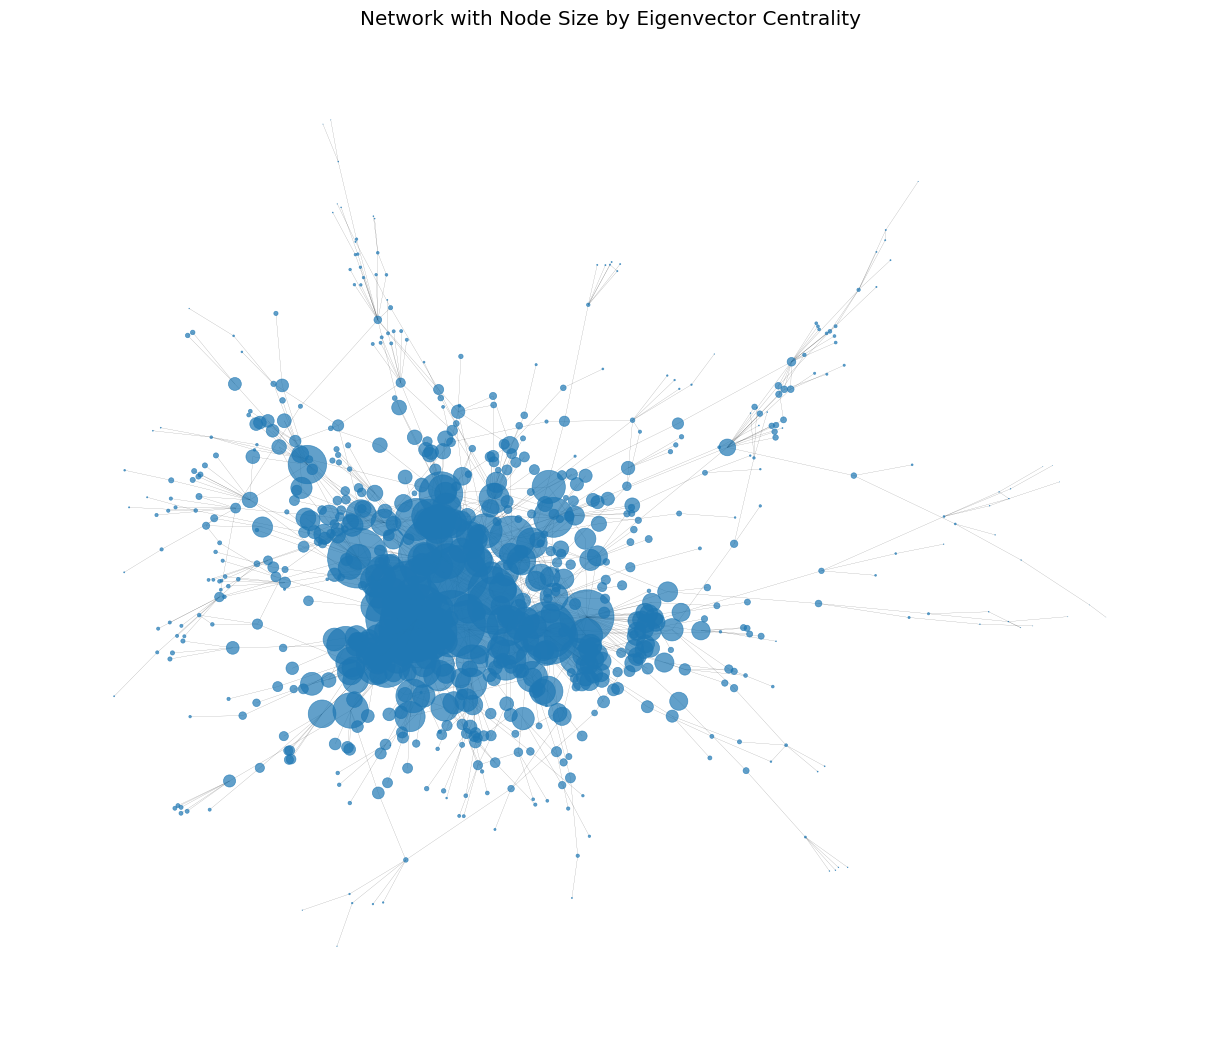

In [ ]:
### Step 27: Network Visualizations with Centrality (2 points)

# Function to create centrality visualization
def plot_centrality(G, centrality, title):
    plt.figure(figsize=(12, 10))
    node_size = [v * 10000 for v in centrality.values()]
    nx.draw(G, node_size=node_size, width=0.1, alpha=0.7)
    plt.title(title)
    plt.show()

# Visualize with degree centrality
plot_centrality(G, degree_centrality, "Network with Node Size by Degree Centrality")

# Visualize with betweenness centrality
plot_centrality(G, betweenness, "Network with Node Size by Betweenness Centrality")

# Visualize with closeness centrality
plot_centrality(G, closeness, "Network with Node Size by Closeness Centrality")

# Visualize with eigenvector centrality
plot_centrality(G, eigenvector, "Network with Node Size by Eigenvector Centrality")